# 3.4 Analyse de Sensibilité au Poids α

Analyser comment le poids α influence les performances de la stratégie de moyenne pondérée.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

# Charger les données
df = pd.read_csv('data/subset_fashion_dataset/products_final.csv')
ground_truth = pd.read_csv('data/subset_fashion_dataset/ground_truth.csv', sep=';')
ground_truth.columns = ground_truth.columns.str.strip()

# Charger les embeddings
text_embeddings = np.load('results/text_embeddings.npy')
vit_embeddings = np.load('results/vit_embeddings.npy')

# Charger les ancres
anchor_ids = ground_truth['anchor_id'].tolist()

print(f"Produits: {len(df)}")
print(f"Ancres: {len(anchor_ids)}")
print(f"Texte: {text_embeddings.shape}")
print(f"ViT: {vit_embeddings.shape}")

Produits: 400
Ancres: 30
Texte: (400, 384)
ViT: (400, 768)


In [2]:
# Préparer les embeddings (normalisation + projection)
text_norm = normalize(text_embeddings, norm='l2')
vit_norm = normalize(vit_embeddings, norm='l2')

# Projeter ViT vers 384 (dimension du texte)
pca_vit = PCA(n_components=384)
vit_proj = pca_vit.fit_transform(vit_norm)

print(f"Texte: {text_norm.shape}")
print(f"ViT projeté: {vit_proj.shape}")

Texte: (400, 384)
ViT projeté: (400, 384)


In [3]:
# Fonction d'évaluation
def evaluate_alpha(alpha, text_proj, vit_proj, df, anchor_ids, ground_truth):
    """Évaluer pour un alpha donné"""
    # Moyenne pondérée
    multimodal = alpha * text_proj + (1 - alpha) * vit_proj
    
    # Similarité
    similarity = cosine_similarity(multimodal)
    
    # Extraire top-5
    results = []
    for anchor_id in anchor_ids:
        anchor_idx = df[df['id'] == anchor_id].index[0]
        sims = list(enumerate(similarity[anchor_idx]))
        sims.sort(key=lambda x: x[1], reverse=True)
        sims = [x for x in sims if x[0] != anchor_idx]
        top5 = [df.iloc[x[0]]['id'] for x in sims[:5]]
        results.append({'anchor_id': anchor_id, 'top5_ids': top5})
    
    # Calculer les métriques
    precisions = []
    recalls = []
    mrrs = []
    
    for res in results:
        pred_ids = set(res['top5_ids'])
        gt_row = ground_truth[ground_truth['anchor_id'] == res['anchor_id']].iloc[0]
        
        true_ids = set()
        for i in range(1, 6):
            gid = gt_row[f'global_id{i}']
            if pd.notna(gid):
                true_ids.add(int(gid))
        
        intersection = pred_ids & true_ids
        precisions.append(len(intersection) / 5)
        recalls.append(len(intersection) / 5)
        
        pred_list = list(res['top5_ids'])
        mrr = 0.0
        for rank, pid in enumerate(pred_list, 1):
            if pid in true_ids:
                mrr = 1.0 / rank
                break
        mrrs.append(mrr)
    
    return {
        'precision': np.mean(precisions),
        'recall': np.mean(recalls),
        'mrr': np.mean(mrrs)
    }

In [4]:
# Tester α de 0 à 1 par pas de 0.1
alphas = np.arange(0, 1.1, 0.1)
results_sensitivity = []

for alpha in alphas:
    metrics = evaluate_alpha(alpha, text_norm, vit_proj, df, anchor_ids, ground_truth)
    results_sensitivity.append({'alpha': alpha, **metrics})
    print(f"α={alpha:.1f}: P@5={metrics['precision']:.3f}, R@5={metrics['recall']:.3f}, MRR={metrics['mrr']:.3f}")

df_sensitivity = pd.DataFrame(results_sensitivity)

α=0.0: P@5=0.460, R@5=0.460, MRR=0.673
α=0.1: P@5=0.460, R@5=0.460, MRR=0.678
α=0.2: P@5=0.473, R@5=0.473, MRR=0.691
α=0.3: P@5=0.473, R@5=0.473, MRR=0.741
α=0.4: P@5=0.493, R@5=0.493, MRR=0.800
α=0.5: P@5=0.500, R@5=0.500, MRR=0.833
α=0.6: P@5=0.480, R@5=0.480, MRR=0.817
α=0.7: P@5=0.447, R@5=0.447, MRR=0.739
α=0.8: P@5=0.393, R@5=0.393, MRR=0.697
α=0.9: P@5=0.373, R@5=0.373, MRR=0.668
α=1.0: P@5=0.367, R@5=0.367, MRR=0.661


Graphique sauvegardé: results/alpha_sensitivity_curve.png


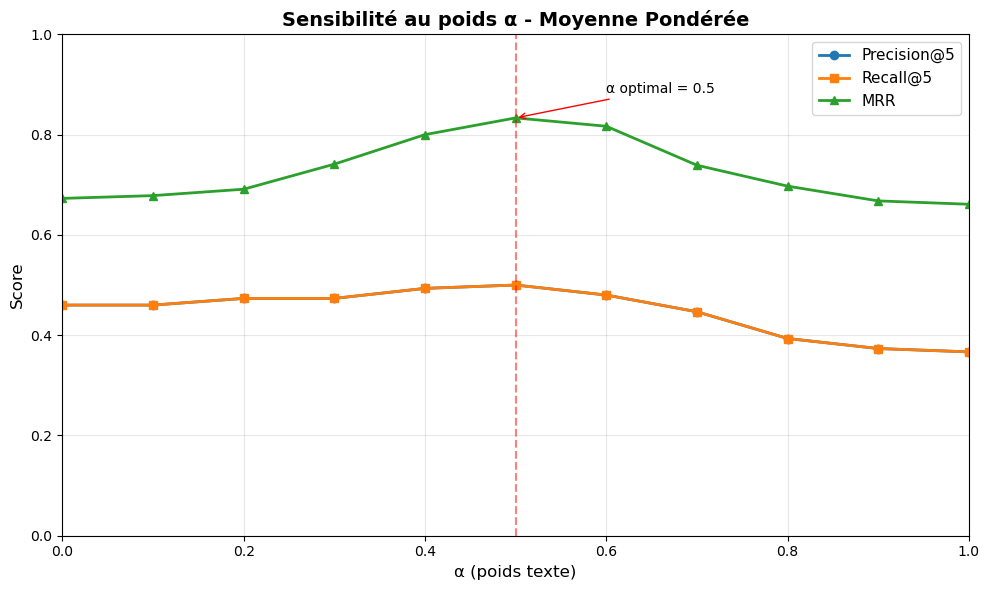

In [5]:
# Tracer les courbes
plt.figure(figsize=(10, 6))
plt.plot(df_sensitivity['alpha'], df_sensitivity['precision'], 'o-', label='Precision@5', linewidth=2)
plt.plot(df_sensitivity['alpha'], df_sensitivity['recall'], 's-', label='Recall@5', linewidth=2)
plt.plot(df_sensitivity['alpha'], df_sensitivity['mrr'], '^-', label='MRR', linewidth=2)

plt.xlabel('α (poids texte)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Sensibilité au poids α - Moyenne Pondérée', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.xlim(0, 1)
plt.ylim(0, 1)

# Marquer l'optimal
best_idx = df_sensitivity['mrr'].idxmax()
best_alpha = df_sensitivity.loc[best_idx, 'alpha']
best_mrr = df_sensitivity.loc[best_idx, 'mrr']
plt.axvline(x=best_alpha, color='red', linestyle='--', alpha=0.5)
plt.annotate(f'α optimal = {best_alpha:.1f}', 
             xy=(best_alpha, best_mrr), 
             xytext=(best_alpha+0.1, best_mrr+0.05),
             fontsize=10,
             arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.savefig('results/alpha_sensitivity_curve.png', dpi=150)
print("Graphique sauvegardé: results/alpha_sensitivity_curve.png")
plt.show()

In [6]:
# Identifier l'optimal pour chaque métrique
best_precision = df_sensitivity.loc[df_sensitivity['precision'].idxmax()]
best_recall = df_sensitivity.loc[df_sensitivity['recall'].idxmax()]
best_mrr = df_sensitivity.loc[df_sensitivity['mrr'].idxmax()]

print("=== α OPTIMAL ===")
print(f"Precision@5: α={best_precision['alpha']:.1f} (score={best_precision['precision']:.3f})")
print(f"Recall@5:    α={best_recall['alpha']:.1f} (score={best_recall['recall']:.3f})")
print(f"MRR:         α={best_mrr['alpha']:.1f} (score={best_mrr['mrr']:.3f})")

=== α OPTIMAL ===
Precision@5: α=0.5 (score=0.500)
Recall@5:    α=0.5 (score=0.500)
MRR:         α=0.5 (score=0.833)


In [7]:
# Interprétation
alpha_optimal = best_mrr['alpha']

print("=== INTERPRÉTATION ===")
if alpha_optimal >= 0.7:
    print(f"α optimal = {alpha_optimal:.1f} (> 0.7)")
    print("→ Le TEXTE domine : les descriptions sont plus fiables que les images")
    print("→ Possible si les descriptions sont détaillées (marque, matière, style)")
elif alpha_optimal <= 0.3:
    print(f"α optimal = {alpha_optimal:.1f} (< 0.3)")
    print("→ L'IMAGE domine : le visuel est plus discriminant que le texte")
    print("→ Possible si les images sont de qualité et variées")
else:
    print(f"α optimal = {alpha_optimal:.1f} (autour de 0.5)")
    print("→ ÉQUILIBRE texte + image : les deux se complémentent")
    print("→ Ni le texte ni l'image ne suffisent seuls")
    print("→ La fusion multimodale apporte une valeur ajoutée")

print(f"\nScore optimal (MRR): {best_mrr['mrr']:.3f}")
print(f"Amélioration vs texte seul (α=1.0): {best_mrr['mrr'] - df_sensitivity[df_sensitivity['alpha']==1.0]['mrr'].values[0]:.3f}")
print(f"Amélioration vs image seule (α=0.0): {best_mrr['mrr'] - df_sensitivity[df_sensitivity['alpha']==0.0]['mrr'].values[0]:.3f}")

=== INTERPRÉTATION ===
α optimal = 0.5 (autour de 0.5)
→ ÉQUILIBRE texte + image : les deux se complémentent
→ Ni le texte ni l'image ne suffisent seuls
→ La fusion multimodale apporte une valeur ajoutée

Score optimal (MRR): 0.833
Amélioration vs texte seul (α=1.0): 0.172
Amélioration vs image seule (α=0.0): 0.161


In [8]:
# Sauvegarder les résultats
df_sensitivity.to_csv('results/alpha_sensitivity.csv', index=False)
print("Résultats sauvegardés: results/alpha_sensitivity.csv")

Résultats sauvegardés: results/alpha_sensitivity.csv


## Conclusion

### α optimal identifié : {:.1f}

### Observations:
1. **Forme de la courbe**: Est-elle symétrique autour de l'optimal ?
2. **Sensibilité**: Les performances chutent-elles rapidement quand on s'éloigne de l'optimal ?
3. **Robustesse**: Y a-t-il une plage d'α acceptable (ex: 0.4-0.6) ?

### Recommandation:
- Utiliser α = {:.1f} pour la production
- Revoir α si le catalogue change (nouveaux types de produits)